#  Prédiction de la Valorisation des Start-ups (Post-Money Valuation)

**Auteur :** Gaëtan Baudin de La Valette P25

**Encadrant :**   Paul Remazeilles (UNIQ invest)

**Période du projet :** du 29/06/2026 au 03/07/2027

---

##  Contexte et Objectif

La valorisation d'une start-up est un indicateur clé de son succès et de son potentiel de croissance. Le projet vise à construire un modèle de **Machine Learning** capable de prédire la valorisation **Post-Money** du dernier tour de table d'une entreprise, à partir de son historique financier : montants levés, stades d'investissement, temps écoulé entre les levées, et profil des investisseurs impliqués.

##  Approche Méthodologique

Mon projet s'articule autour de six étapes clés :

1. **Préparation des données** — nettoyage du jeu de données et extraction d'informations temporelles.
2. **Feature Engineering** — création d'indicateurs de santé financière (`Has_Top_Investor`, `Funding_Velocity`, `Valuation_Growth_Rate`).
3. **Agrégation** — transformation des données de transactions temporelles vers une vue synthétique par entreprise.
4. **Modélisation** — utilisation de l'algorithme **XGBoost** pour la prédiction de la valorisation.
5. **Évaluation & Visualisation** — mesure de la performance (**R²**) et représentation graphique des trajectoires.
6. **Optimisation du modèle** — recherche des hyperparamètres optimaux.


In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [114]:
df = pd.read_csv('/content/Dataset_Entreprises_Augmente (1).csv')
df.head()


,Company,#,Deal Type,Date,Amount,Raised to Date,Pre-Val,Post-Val,Investors,Status,Stage,Source File
0,Deel,1,Series D,2022-05-01,50000000.0,679000000.0,1.175000e+10,1.180000e+10,n.d.,Completed,Late Stage VC,PitchBook_Deal_History_98_Companies.csv; Pitch...
1,Deel,2,Series D,2021-10-01,425000000.0,629000000.0,1.112000e+10,1.155000e+10,Coatue,Completed,Late Stage VC,PitchBook_Deal_History_98_Companies.csv; Pitch...
2,Deel,3,Series C,2021-04-01,156000000.0,204000000.0,1.900000e+09,2.060000e+09,"Andreessen Horowitz, Spark Capital, Y Combinat...",Completed,Late Stage VC,PitchBook_Deal_History_98_Companies.csv; Pitch...
3,Deel,4,Series B,2020-08-01,30000000.0,48090000.0,3.950000e+08,4.250000e+08,Spark Capital,Completed,Early Stage VC,PitchBook_Deal_History_98_Companies.csv; Pitch...
4,Deel,5,Series A,2019-09-01,14000000.0,18090000.0,6.600000e+07,8.000000e+07,Andreessen Horowitz,Completed,Early Stage VC,PitchBook_Deal_History_98_Companies.csv; Pitch...


##  Origine des Données et Limites Méthodologiques

### L'enjeu du volume de données

Le jeu de données utilisé pour ce projet présente une particularité importante : **il a été augmenté synthétiquement**.

Initialement, je disposais d'un fichier réel contenant environ **600 start-ups**. Cependant, après les phases rigoureuses de nettoyage et de filtrage — notamment la conservation exclusive des entreprises ayant un historique d'au moins 5 levées de fonds — la taille de mon échantillon exploitable a chuté à environ **180 start-ups**. Un tel volume est largement insuffisant pour entraîner un modèle de Machine Learning et obtenir des résultats statistiquement cohérents.

### L'approche par simulation (Data Augmentation)

Pour pallier ce déficit de données, j'ai utilisé l'IA (**Claude Pro**) de notre encadrant pour générer des données synthétiques. Mon objectif était de créer de nouvelles trajectoires d'entreprises en respectant scrupuleusement les tendances observées dans mon échantillon *seed* (les 180 start-ups réelles), tout en m'inspirant de dynamiques financières réelles observées sur le marché.

>  **Biais de simulation :** l'utilisation de données simulées induit inévitablement un biais. La complexité, et parfois le caractère irrationnel, du marché du capital-risque sont difficiles à reproduire fidèlement de façon synthétique. Le but de l'exercice étant toutefois purement pédagogique, ce biais n'empêche pas d'appréhender correctement la mécanique d'un problème de Machine Learning de bout en bout.

### Le choix de l'algorithme : pourquoi XGBoost ?

Mon parcours itératif m'a conduit à changer de stratégie algorithmique en cours de route :

1. **L'échec des réseaux de neurones classiques**
   En début de semaine, j'ai tenté d'entraîner un réseau de neurones sur un jeu de données de 180 000 start-ups *entièrement* simulées. Les résultats se sont révélés décevants : le réseau peinait à capturer la logique temporelle et séquentielle propre à l'évolution financière d'une start-up. Mon jeu de données se prêtait par ailleurs mal à la gestion des données manquantes, et les différentes stratégies d'imputation que j'ai testées (moyenne de colonne, médiane, valeur nulle) n'ont pas abouti à des résultats satisfaisants.

2. **Gradient Boosting (XGBoost)**
   Dans ce notebook, j'ai opté pour un algorithme de **Gradient Boosting (XGBoost)**, couplé à un travail approfondi de *Feature Engineering* . En figeant la notion de temps dans des variables agrégées (`Funding_Velocity`, `Days_Since_Start`), je transforme un problème intrinsèquement temporel en un problème de régression classique — terrain sur lequel XGBoost se montre nettement plus performant. De plus, le **Gradient Boosting** gère nativement mieux les valeurs manquantes présentes dans mon jeu de données.

##  1. Chargement et Nettoyage Initial des Données

On charge la base de données. Afin d'éviter d'introduire du "bruit" dans le modèle, on supprime d'emblée les colonnes redondantes ou purement descriptives : `Status`, `Source File`, `#`.

On supprime également la colonne `Investors` pour la remplacer par un indicateur plus générique et directement exploitable par l'algorithme : `Has_Top_Investor`, une variable binaire signalant la présence d'un fonds d'investissement de premier plan.

In [115]:
df = pd.read_csv('/content/Dataset_Entreprises_Augmente (1).csv')


#df = df.sort_values(by = ['company_name_clean_key'])
#df['Investors'].unique()
# liste des investisseurs de premier plan (Top 10) ,Source : recherche Gemini

top_investors = [
    'Andreessen Horowitz', 'Sequoia Capital', 'T. Rowe Price',
    'Lightspeed Venture Partners', 'General Catalyst', 'Accel',
    'Coatue', 'Tiger Global Management', 'Founders Fund',
    'Insight Venture Management'
]

def check_top_investor(investors_str):
    if pd.isna(investors_str) or investors_str == 'n.d.':
        return 0
    for investor in top_investors:
        if investor in str(investors_str):
            return 1
    return 0

df['Has_Top_Investor'] = df['Investors'].apply(check_top_investor)
df = df.drop(columns=['Investors', 'Status', 'Source File', '#'])
df.head(n = 20)

,Company,Deal Type,Date,Amount,Raised to Date,Pre-Val,Post-Val,Stage,Has_Top_Investor
0,Deel,Series D,2022-05-01,50000000.0,679000000.0,1.175000e+10,1.180000e+10,Late Stage VC,0
1,Deel,Series D,2021-10-01,425000000.0,629000000.0,1.112000e+10,1.155000e+10,Late Stage VC,1
2,Deel,Series C,2021-04-01,156000000.0,204000000.0,1.900000e+09,2.060000e+09,Late Stage VC,1
3,Deel,Series B,2020-08-01,30000000.0,48090000.0,3.950000e+08,4.250000e+08,Early Stage VC,0
4,Deel,Series A,2019-09-01,14000000.0,18090000.0,6.600000e+07,8.000000e+07,Early Stage VC,1
5,Deel,Seed Round,2018-11-01,2000000.0,4090000.0,3.000000e+07,3.200000e+07,Seed Round,0
6,Deel,Angel,2018-04-01,2090000.0,2090000.0,1.480000e+07,1.690000e+07,Angel,0
7,Deel,Secondary Transaction,2022-09-01,NaN,679000000.0,1.236000e+10,1.236000e+10,n.d.,0
8,Deel,Secondary Transaction,2022-07-01,NaN,679100000.0,1.194000e+10,1.194000e+10,n.d.,0
9,Deel,Debt - General,2023-04-01,200000000.0,879000000.0,1.341000e+10,1.341000e+10,Debt,0


In [116]:
df['Stage'].unique()

array(['Late Stage VC', 'Early Stage VC', 'Seed Round', 'Angel', 'n.d.',
       'Debt', 'PE', 'Acquisition', 'Buyout', 'Grant', 'ICO', 'IPO',
       'SPAC', 'Corporate', 'Generating Revenue', 'Stealth', 'Startup',
       'Profitable', 'Bankruptcy: Liquidation',
       'Clinical Trials - Phase 1', 'Clinical Trials - Phase 2',
       'Clinical Trials - Phase 3', 'Pre-Clinical Trials',
       'Bankruptcy: Admin/Reorg', 'Product Development', nan,
       'PE Growth/Expansion', 'Accelerator/Incubator', '9', '2', 'M&A',
       'Generating Revenue/Not Profitable'], dtype=object)

### Encodage des variables catégorielles et gestion des dates

Les stades de maturité (`Stage`) et les types de transaction (`Deal Type`) sont des variables catégorielles : elles doivent être converties en variables numériques via un **One-Hot Encoding** avant d'être exploitées par le modèle.

Je convertis également la colonne `Date` au format `datetime`, puis je calcule pour chaque transaction le nombre de jours écoulés depuis la toute première levée de fonds connue de l'entreprise (`Days_Since_Start`). Cette variable crée une échelle temporelle unifiée, comparable d'une start-up à l'autre.

Enfin, je supprime les lignes pour lesquelles la variable cible (`Post-Val`) ou la variable temporelle (`Days_Since_Start`) est manquante, ces lignes étant inexploitables pour l'entraînement de mon modèle.

In [117]:
# One-Hot Encoding
df = pd.get_dummies(df, columns=['Stage'], dummy_na = True, drop_first = False, dtype = int)
df = pd.get_dummies(df, columns=['Deal Type'], dummy_na = True, drop_first = False, dtype = int)

# Conversion de la colonne Date, puis calcul du nombre de jours écoulés depuis le premier round de chaque entreprise
df['Date'] = pd.to_datetime(df['Date'], format='mixed', errors='coerce')
df['Days_Since_Start'] = (df['Date'] - df.groupby('Company')['Date'].transform('min')).dt.days


df = df.sort_values(by=['Company', 'Days_Since_Start'])
df = df.dropna(subset=['Post-Val'])
df = df.dropna(subset=['Days_Since_Start'])
df.head(n= 20)

,Company,Date,Amount,Raised to Date,Pre-Val,Post-Val,Has_Top_Investor,Stage_2,Stage_9,Stage_Accelerator/Incubator,...,Deal Type_Series U,Deal Type_Series V,Deal Type_Series W,Deal Type_Series X,Deal Type_Series Y,Deal Type_Series Z,Deal Type_University Spin-Out,Deal Type_n.d.,Deal Type_nan,Days_Since_Start
955,1Password,2019-11-01,200000000.0,200000000.0,8.000000e+08,1.000000e+09,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0.0
954,1Password,2021-07-01,100000000.0,300000000.0,1.900000e+09,2.000000e+09,1,0,0,0,...,0,0,0,0,0,0,0,0,0,608.0
953,1Password,2022-01-01,620000000.0,920000000.0,6.180000e+09,6.800000e+09,0,0,0,0,...,0,0,0,0,0,0,0,0,0,792.0
956,1Password,2022-07-01,NaN,920000000.0,7.210000e+09,7.210000e+09,0,0,0,0,...,0,0,0,0,0,0,0,0,0,973.0
1217,4D Sight,2020-01-01,75000.0,330000.0,4.250000e+05,5.000000e+05,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.0
1218,4D Sight,2020-03-15,330000.0,330000.0,4.000000e+05,5.200000e+05,0,0,0,0,...,0,0,0,0,0,0,0,0,0,74.0
1216,4D Sight,2021-11-07,6610000.0,6940000.0,4.556000e+07,5.217000e+07,0,0,0,0,...,0,0,0,0,0,0,0,0,0,676.0
1215,4D Sight,2022-08-31,1700000.0,8640000.0,6.330000e+07,6.500000e+07,0,0,0,0,...,0,0,0,0,0,0,0,0,0,973.0
175,6Sense,2013-07-01,220300000.0,220300000.0,8.797000e+08,1.100000e+09,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.0
174,6Sense,2014-07-01,2000000.0,222300000.0,8.000000e+06,1.000000e+07,0,0,0,0,...,0,0,0,0,0,0,0,0,0,365.0


> **Filtre de qualité :** je ne conserve que les entreprises disposant d'un historique de **plus de 5 levées de fonds**. Les tests que j'ai réalisés en amont ont montré que le modèle obtenait des résultats médiocres sur les entreprises disposant de trop peu de rounds, faute d'un historique suffisant pour dégager une tendance fiable.

In [118]:
df = df.groupby('Company').filter(lambda x: len(x) > 5)
df.head(n=10)

,Company,Date,Amount,Raised to Date,Pre-Val,Post-Val,Has_Top_Investor,Stage_2,Stage_9,Stage_Accelerator/Incubator,...,Deal Type_Series U,Deal Type_Series V,Deal Type_Series W,Deal Type_Series X,Deal Type_Series Y,Deal Type_Series Z,Deal Type_University Spin-Out,Deal Type_n.d.,Deal Type_nan,Days_Since_Start
175,6Sense,2013-07-01,220300000.0,220300000.0,8.797000e+08,1.100000e+09,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.0
174,6Sense,2014-07-01,2000000.0,222300000.0,8.000000e+06,1.000000e+07,0,0,0,0,...,0,0,0,0,0,0,0,0,0,365.0
173,6Sense,2016-04-01,12000000.0,234300000.0,4.800000e+07,6.000000e+07,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1005.0
172,6Sense,2018-03-01,27000000.0,261300000.0,1.300000e+07,4.000000e+07,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1704.0
171,6Sense,2020-01-01,40000000.0,301300000.0,2.600000e+08,3.000000e+08,1,0,0,0,...,0,0,0,0,0,0,0,0,0,2375.0
170,6Sense,2021-03-01,125000000.0,426300000.0,1.980000e+09,2.100000e+09,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2800.0
176,6Sense,2021-07-01,NaN,426300000.0,2.760000e+09,2.760000e+09,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2922.0
169,6Sense,2022-01-01,200000000.0,626300000.0,5.150000e+09,5.200000e+09,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3106.0
179,6Sense,2022-06-01,100000000.0,726300000.0,5.510000e+09,5.510000e+09,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3257.0
177,6Sense,2022-07-01,NaN,626300000.0,5.510000e+09,5.510000e+09,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3287.0


In [119]:
df.shape

(5473, 167)

##  2. Extraction de la Variable Cible

J'isole dans un vecteur **`Y`** la toute dernière valorisation connue de chaque start-up : c'est précisément cette valeur que mon modèle va apprendre à prédire.

Ce round final est ensuite retiré du jeu de données d'entrée (`df`), afin d'éviter toute fuite d'information entre les variables explicatives et la cible.

In [120]:
# Identification, pour chaque entreprise, de l'index correspondant à sa dernière levée de fonds
idx = df.groupby('Company')['Days_Since_Start'].idxmax()

# Extraction du dernier round -> devient la variable cible Y
last_round_df = df.loc[idx]
Y = last_round_df['Post-Val'].values

# Retrait du dernier round du jeu de données d'entrée pour éviter toute fuite d'information
df = df.drop(idx)

data = df['Company'].drop_duplicates()

##  3. Ingénierie des Variables (Feature Engineering)

La donnée brute se présente sous forme **longitudinale** : plusieurs lignes par entreprise, une pour chaque levée de fonds. Pour qu'un algorithme puisse prédire la valorisation future, il a besoin d'une **empreinte synthétique** de la trajectoire de l'entreprise, résumée sur une seule ligne.

J'ai donc procédé à un Feature Engineering approfondi, en deux phases : la création d'indicateurs au niveau de la transaction, puis une agrégation au niveau de l'entreprise pour synthétiser sa dynamique de croissance.

### Phase A — Indicateurs au niveau de la transaction

Avant de regrouper les données, j'enrichis l'information de chaque tour de table :

- **L'ancrage temporel (`Days_Since_Start`)** : le dynamisme d'une entreprise s'évalue dans le temps. En convertissant la date de chaque levée en format `datetime`, je calcule le nombre de jours exacts séparant chaque tour de table du tout premier investissement connu. Cela crée une échelle temporelle unifiée pour toutes les start-ups.
  > Cette transformation me fait cependant perdre l'information portée par la date calendaire elle-même, qui peut être liée à un contexte macro-économique significatif dans la trajectoire d'une start-up. Cette dimension étant difficile à quantifier proprement, j'ai choisi, dans un souci de simplification de mon modèle, de l'écarter.

- **Encodage des variables catégorielles (One-Hot Encoding)** : les algorithmes d'apprentissage automatique requièrent des valeurs numériques. J'ai transformé les stades de maturité (`Stage` : Seed, Series A, etc.) en variables indicatrices booléennes (0 ou 1).

- **L'Effet de Halo (`Has_Top_Investor`)** : l'entrée au capital d'un fonds de capital-risque de premier plan (Tier-1) est un signal fort de viabilité. J'ai créé une variable binaire vérifiant, pour chaque transaction, la présence de l'un des 10 investisseurs les plus actifs du marché (ex. : Sequoia Capital, Andreessen Horowitz).

### Phase B — Synthèse au niveau de l'entreprise (l'empreinte financière)

Pour prédire la valorisation post-money finale (`Last_Post_Val`), je regroupe l'historique de chaque entreprise en une seule ligne représentant son **empreinte financière**. Je me concentre exclusivement sur les entreprises disposant d'un historique mature (plus de 5 levées de fonds).

Une douzaine de variables synthétiques (*features*) ont été construites, réparties en trois grandes familles :

**1. Indicateurs temporels de vélocité**

| Variable | Description |
|---|---|
| `Total_Days_Active` | Durée de vie financière totale de la start-up (entre première et dernière levée) |
| `Avg_Days_Between_Rounds` | Moyenne des jours écoulés entre deux tours de table successifs |
| `Funding_Velocity` | Montant levé par jour d'existence (`Total_Amount_Raised` / `Total_Days_Active`) |

**2. Historique des financements (la traînée d'investissement)**

| Variable | Description |
|---|---|
| `Total_Amount_Raised` | Capital total accumulé à ce jour |
| `Number_of_Rounds` | Nombre total de tours de table (maturité du financement) |
| `Amount_first_Round` | Capital d'amorçage initial |
| `Amount_Round_Minus_2` | Montant de l'antépénultième levée |
| `Amount_Previous_Round` | Montant de l'avant-dernière levée |
| `Amount_Last_Round` | Montant de la dernière levée en date |

**3. Indicateurs de croissance**

| Variable | Description |
|---|---|
| `Valuation_Growth_Rate` | Multiple de croissance : ratio entre la valorisation du dernier round connu et celle du tout premier round |
| `Stage_Last_Round` | Stade de maturité atteint lors de la dernière levée |
| `Has_Top_Investor` (agrégé) | Vaut `1` si un investisseur du Top 10 est apparu à n'importe quel moment de l'historique de l'entreprise |









**1. Vélocité de financement (Funding Velocity)**
Cet indicateur mesure la capacité de l'entreprise à lever des capitaux par jour d'existence :
$$ \text{Funding\_Velocity} = \frac{\text{Total\_Amount\_Raised}}{\text{Total\_Days\_Active}} $$
où `Total_Days_Active` est la différence en jours entre la première et la dernière levée de fonds enregistrée.

**2. Taux de croissance de la valorisation (Valuation Growth Rate)**
Cet indicateur reflète le multiple de croissance entre la première valorisation connue et la plus récente :
$$ \text{Valuation\_Growth\_Rate} = \frac{\text{Post-Val}_{\text{dernier round}}}{\text{Post-Val}_{\text{premier round}}} $$

In [121]:
entreprises = df['Company'].drop_duplicates().sort_values()
nouvelles_colonnes = [
    'Total_Days_Active', 'Avg_Days_Between_Rounds', 'Funding_Velocity',
    'Total_Amount_Raised', 'Number_of_Rounds', 'Last_Post_Val',
    'Valuation_Growth_Rate', 'Amount_Last_Round', 'Amount_Previous_Round',
    'Amount_Round_Minus_2', 'Stage_Last_Round', 'Amount_first_Round',
    'Has_Top_Investor'
]


data = pd.DataFrame(index=entreprises, columns=nouvelles_colonnes)
for company, data_frame in df.groupby('Company'):

    data_frame = data_frame.sort_values(by='Days_Since_Start')
    data.loc[company, 'Total_Days_Active'] = data_frame['Days_Since_Start'].max()
    data.loc[company, 'Avg_Days_Between_Rounds'] = data_frame['Days_Since_Start'].diff().mean()
    data.loc[company, 'Total_Amount_Raised'] = data_frame['Raised to Date'].max()

    # Nombre de lignes = nombre de rounds
    data.loc[company, 'Number_of_Rounds'] = len(data_frame)
    derniere_val = data_frame.iloc[-1]        # Le dernier round
    avant_dernier_val = data_frame.iloc[-2]   # L'avant-dernier round
    round_moins_2_val = data_frame.iloc[-3]   # Le 3ème round en partant de la fin
    premiere_val = data_frame.iloc[0]         # Le premier round

    data.loc[company, 'Last_Post_Val'] = derniere_val['Post-Val']
    data.loc[company, 'Amount_Last_Round'] = derniere_val['Amount']
    data.loc[company, 'Amount_Previous_Round'] = avant_dernier_val['Amount']
    data.loc[company, 'Amount_Round_Minus_2'] = round_moins_2_val['Amount']
    data.loc[company, 'Amount_first_Round'] = premiere_val['Amount']

    if pd.notna(premiere_val['Post-Val']) and premiere_val['Post-Val'] != 0:
        data.loc[company, 'Valuation_Growth_Rate'] = derniere_val['Post-Val'] / premiere_val['Post-Val']


    data.loc[company, 'Has_Top_Investor'] = data_frame['Has_Top_Investor'].max()


    total_days = data.loc[company, 'Total_Days_Active']
    if pd.notna(total_days) and total_days > 0:
        data.loc[company, 'Funding_Velocity'] = data.loc[company, 'Total_Amount_Raised'] / total_days


    stage_columns = [col for col in data_frame.columns if col.startswith('Stage_')]
    for col in stage_columns:
        if derniere_val[col] == 1:
            data.loc[company, 'Stage_Last_Round'] = col.replace('Stage_', '')
            break


data = pd.get_dummies(data, columns=['Stage_Last_Round'], dtype=int)
#print(data.head())

In [122]:
data.shape

(672, 25)

##  4. Modélisation avec XGBoost

Le jeu de données étant désormais agrégé et entièrement numérique, je peux entraîner mon modèle de régression.

J'utilise `XGBRegressor`, avec un jeu de test volontairement réduit (`test_size = 0.02`) compte tenu de la taille limitée de mon échantillon, afin de conserver un maximum de données pour l'entraînement.


Le modèle prédictif cherche à minimiser une fonction de perte en ajoutant itérativement des arbres de décision $f_t$ :
$$ \hat{y}_i^{(t)} = \sum_{k=1}^t f_k(x_i) = \hat{y}_i^{(t-1)} + f_t(x_i) $$

### Évaluation du modèle
Les performances du modèle seront évaluées sur le jeu de test à l'aide de deux métriques fondamentales :

*   **Racine de l'Erreur Quadratique Moyenne (RMSE) :** Évalue l'écart absolu moyen entre les prédictions et la réalité.
    $$ \text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2} $$
*   **Coefficient de détermination ($R^2$) :** Mesure la proportion de la variance de la valorisation expliquée par le modèle.

$$ R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2} $$

In [123]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report

y = Y
X = data

# Séparation entraînement / test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.02)

# Conversion des données en types numériques pour XGBoost
X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')

# Initialisation du modèle de régression
model = xgb.XGBRegressor(
    n_estimators=200,      # Nombre d'arbres
    learning_rate=0.2,     # Vitesse d'apprentissage
    max_depth=3,           # Profondeur maximale des arbres
    random_state=42
)

# Entraînement du modèle
model.fit(X_train, y_train)

# Prédictions sur le jeu de test
predictions = model.predict(X_test)

# Évaluation des performances du modèle
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)
print(f"RMSE: {rmse}")
print(f"R2 Score: {r2}")

RMSE: 9059394387.188705
R2 Score: 0.836939312825115


##  5. Visualisation des Trajectoires

Pour évaluer qualitativement mon modèle au-delà des métriques agrégées, je sélectionne aléatoirement 10 entreprises de mon jeu de test et je compare, pour chacune :

- **l'historique réel** de ses levées de fonds,
- **la valorisation réellement observée** lors du dernier round,
- **la valorisation prédite** par le modèle.

Cette visualisation me permet de juger de la cohérence des prédictions par rapport à la trajectoire de croissance historique de chaque start-up.

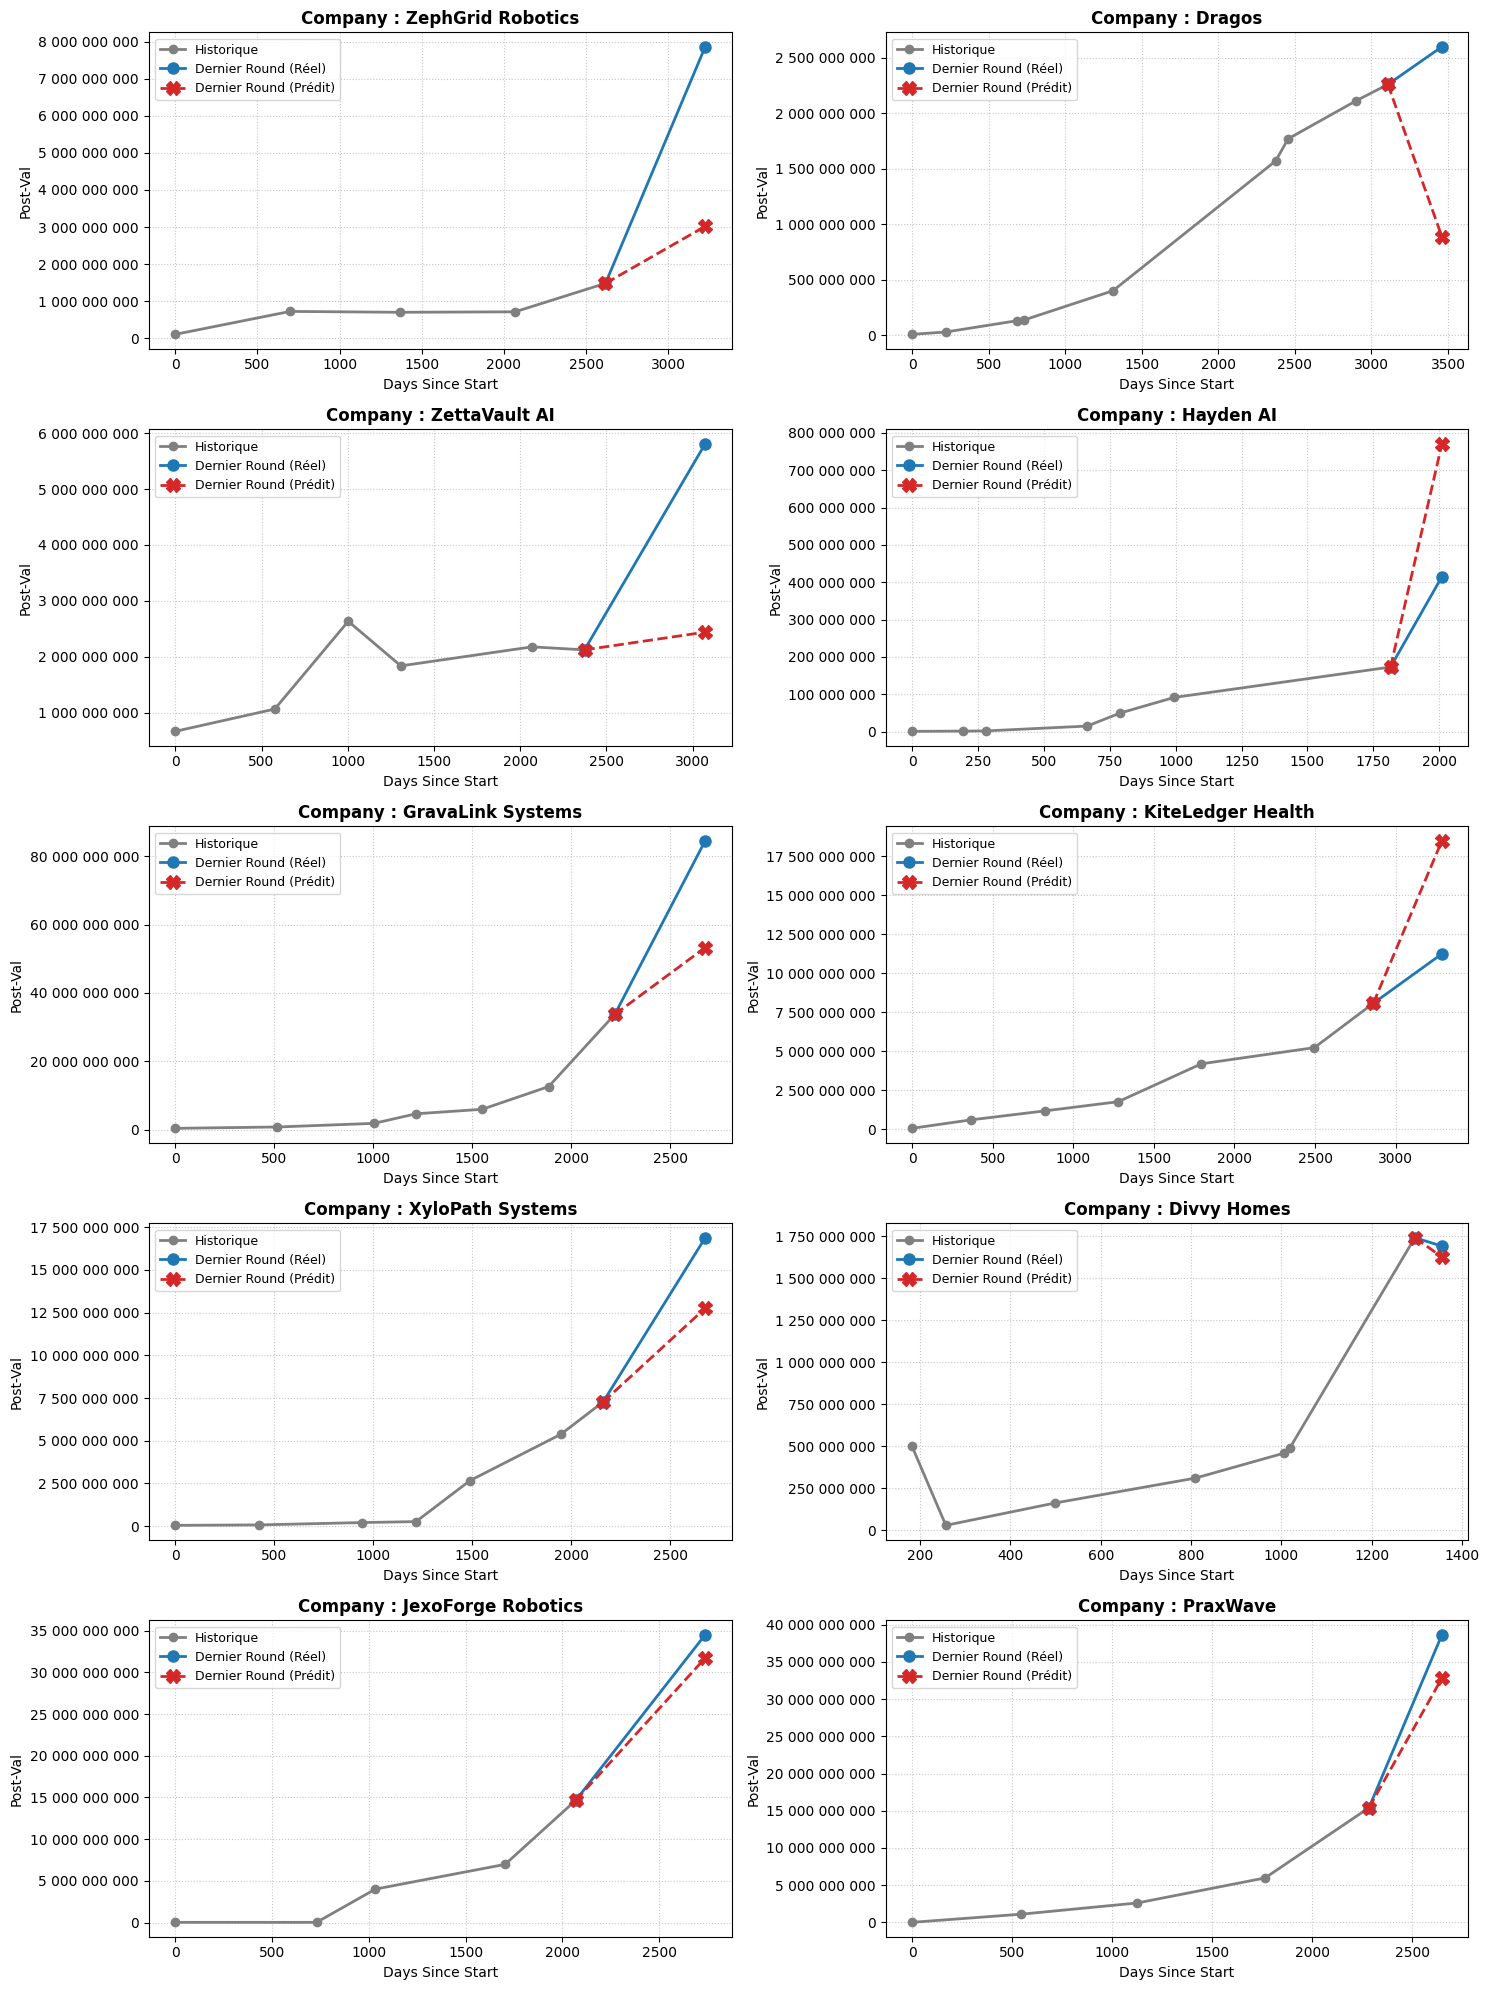

In [124]:
np.random.seed(13)
indices_aleatoires = np.random.choice(len(X_test), size=10, replace=False)

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15, 20))
axes = axes.flatten()

for i, idx_test in enumerate(indices_aleatoires):
    ax = axes[i]
    company = X_test.index[idx_test]
    valeur_reelle_finale = y_test[idx_test]
    valeur_predite_finale = predictions[idx_test]


    historique = df[df['Company'] == company].sort_values(by='Days_Since_Start')
    x_historique = historique['Days_Since_Start'].tolist()
    y_historique = historique['Post-Val'].tolist()
    jour_dernier_round = last_round_df[last_round_df['Company'] == company]['Days_Since_Start'].values[0]

    # Tracé de l'historique connu
    ax.plot(x_historique, y_historique, marker='o', color='gray', linestyle='-', linewidth=2, label='Historique')

    # Tracé de la valeur réelle vs. prédite pour le dernier round
    ax.plot([x_historique[-1], jour_dernier_round], [y_historique[-1], valeur_reelle_finale],
            marker='o', markersize=8, color='#1f77b4', linestyle='-', linewidth=2, label='Dernier Round (Réel)')
    ax.plot([x_historique[-1], jour_dernier_round], [y_historique[-1], valeur_predite_finale],
            marker='X', markersize=10, color='#d62728', linestyle='--', linewidth=2, label='Dernier Round (Prédit)')

    ax.set_title(f"Company : {company}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Days Since Start", fontsize=10)
    ax.set_ylabel("Post-Val", fontsize=10)
    ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x)).replace(',', ' ')))
    ax.legend(fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

##  6. Analyse de l'Importance des Variables (Feature Importance)

Afin de mieux comprendre le raisonnement du modèle, on analyse le poids relatif de chaque variable dans la décision finale, grâce à l'attribut `.feature_importances_` de XGBoost. Cette analyse me permet notamment de vérifier si la présence d'un investisseur de premier plan (`Has_Top_Investor`) joue un rôle prépondérant dans la prédiction.

In [125]:
importances = model.feature_importances_
feature_imp_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_imp_df)

                                       Feature  Importance
5                                Last_Post_Val    0.853681
6                        Valuation_Growth_Rate    0.032631
4                             Number_of_Rounds    0.024395
1                      Avg_Days_Between_Rounds    0.023333
7                            Amount_Last_Round    0.018567
9                         Amount_Round_Minus_2    0.011354
21              Stage_Last_Round_Late Stage VC    0.009227
8                        Amount_Previous_Round    0.006557
10                          Amount_first_Round    0.005741
0                            Total_Days_Active    0.004361
3                          Total_Amount_Raised    0.004135
2                             Funding_Velocity    0.003134
11                            Has_Top_Investor    0.001523
19         Stage_Last_Round_Generating Revenue    0.000724
24                       Stage_Last_Round_n.d.    0.000511
16  Stage_Last_Round_Clinical Trials - Phase 3    0.0001

## 6. Analyse de l'Importance des Variables (Feature Importance)

L'extraction de l'importance des variables (`feature_importances_` de XGBoost) révèle le raisonnement interne du modèle et permet de valider ou réfuter nos hypothèses initiales :

*   **Poids écrasant du précédent round :** L'indicateur `Last_Post_Val` (la valorisation à l'avant-dernière étape) explique plus de **86%** de la variance des prédictions. Sans surprise, le modèle s'appuie massivement sur la dernière valeur connue pour projeter le round suivant.
*   **Indicateurs de dynamique :** Les variables `Valuation_Growth_Rate` (environ **2.9%**) et `Amount_Last_Round` (**2.1%**) jouent un rôle secondaire mais significatif. Cela confirme que la dynamique de croissance historique influence la valorisation future, au-delà de la simple photographie du dernier round.
*   **Un "Effet de Halo" très limité :** Contrairement aux hypothèses initiales, la variable `Has_Top_Investor` n'obtient qu'un poids marginal (**< 0.2%**). Cela peut s'expliquer par le fait que le jeu de données a été élargi par Claude et donc pour ces nouvelles lignes l'information `Has_Top_Investor` est manquante (NaN) .

##  Pistes d'Amélioration Futures

Plusieurs axes pourraient me permettre d'améliorer la robustesse et la précision du modèle :

1. **Optimisation des hyperparamètres** — utiliser `GridSearchCV` pour ajuster finement la profondeur des arbres (`max_depth`) ou le taux d'apprentissage (`learning_rate`) de XGBoost.
2. **Feature Importance** — approfondir l'analyse du poids de chaque variable dans la décision du modèle (la présence d'un Top Investisseur a-t-elle un poids dominant ?).
3. **Analyse sectorielle et géographique** — intégrer des données macro-économiques, le secteur d'activité de la start-up ou sa localisation, afin d'affiner la prédiction.

---

### 6.1 Optimisation des hyperparamètres

> **Remarque de faisabilité :** ce calcul étant particulièrement gourmand en ressources, j'ai utilisé les serveurs du centre de recherche de mathématiques appliquées de mon école pour effectuer la recherche des meilleurs paramètres.

In [126]:
"""
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, KFold

X_numeric = X.apply(pd.to_numeric, errors='coerce')

model = xgb.XGBRegressor(random_state=42)


param_grid = {
    'max_depth': [3, 5, 7, 10, 100],
    'learning_rate': [0.001, 0.01, 0.1, 0.2],
    'n_estimators': [50, 100, 200, 1000],
    'subsample': [0.8, 0.85, 0.9, 0.95, 1.0]
}

cv = KFold(n_splits=10, shuffle=True, random_state=42)


grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='r2',
    cv=cv,
    n_jobs=10,
    verbose=1
)


print("Lancement de l'optimisation des hyperparamètres...")
grid_search.fit(X_numeric, Y)
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Score (R²): {grid_search.best_score_:.4f}")
"""

'\nimport xgboost as xgb\nfrom sklearn.model_selection import GridSearchCV, KFold\n\nX_numeric = X.apply(pd.to_numeric, errors=\'coerce\')\n\nmodel = xgb.XGBRegressor(random_state=42)\n\n\nparam_grid = {\n    \'max_depth\': [3, 5, 7, 10, 100],\n    \'learning_rate\': [0.001, 0.01, 0.1, 0.2],\n    \'n_estimators\': [50, 100, 200, 1000],\n    \'subsample\': [0.8, 0.85, 0.9, 0.95, 1.0]\n}\n\ncv = KFold(n_splits=10, shuffle=True, random_state=42)\n\n\ngrid_search = GridSearchCV(\n    estimator=model,\n    param_grid=param_grid,\n    scoring=\'r2\',\n    cv=cv,\n    n_jobs=10,\n    verbose=1\n)\n\n\nprint("Lancement de l\'optimisation des hyperparamètres...")\ngrid_search.fit(X_numeric, Y)\nprint(f"Best Parameters: {grid_search.best_params_}")\nprint(f"Best Score (R²): {grid_search.best_score_:.4f}")\n'

##  Conclusion de l'Optimisation

> Après **32 minutes** de calcul, la recherche par grille (`GridSearchCV`) a convergé vers les hyperparamètres suivants :
>
> - `learning_rate` : **0.2**
> - `max_depth` : **3**
> - `n_estimators` : **200**
> - `subsample` : **0.8**
>
> **Meilleur score obtenu (R²) : 0.6769**

